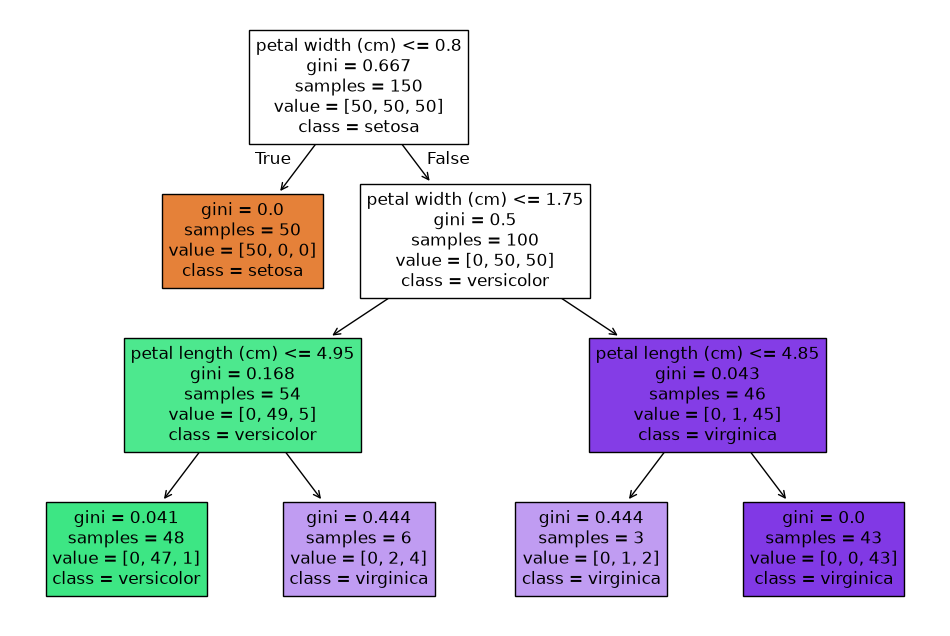

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 데이터 로드 및 모델 학습
iris = load_iris()
X, y = iris.data, iris.target
model = DecisionTreeClassifier(max_depth=3)
model.fit(X, y)

# 트리 시각화
plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

In [4]:
from collections import Counter

# 어떤 리프 노드에 도달한 샘플들의 실제 클래스
leaf_samples = ['A', 'A', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'A']

counts = Counter(leaf_samples)
total = len(leaf_samples)

probs = {cls: cnt / total for cls, cnt in counts.items()}
print(probs)   # 예: {'A': 0.8, 'B': 0.2}

{'A': 0.8, 'B': 0.2}


In [5]:
from collections import Counter

# 한 노드에 있는 샘플들의 클래스
node = ['A', 'A', 'B', 'A', 'B', 'A']

counts = Counter(node)
total = len(node)

gini = 1 - sum((cnt/total)**2 for cnt in counts.values())
print(round(gini, 3))   # 예: 0.444

0.444


In [6]:
import math
from collections import Counter

# 한 노드에 있는 샘플의 클래스 구성
node = ['A', 'A', 'B', 'A', 'B', 'A']

counts = Counter(node)
total = len(node)

entropy = -sum((cnt/total) * math.log2(cnt/total) for cnt in counts.values())
print(round(entropy, 3))   # 예: 0.918

0.918


In [10]:
import math
from collections import Counter

def entropy(labels):
    total = len(labels)
    counts = Counter(labels)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

# 전체 데이터의 클래스
D = ['A', 'A', 'B', 'A', 'B', 'A']   # 엔트로피 계산
H_D = entropy(D)

# 속성 A로 분할한 경우
Dv1 = ['A', 'A', 'A']   # 예: feature A = 0 그룹
Dv2 = ['B', 'A', 'B']   # 예: feature A = 1 그룹

H_split = (len(Dv1)/len(D)) * entropy(Dv1) + \
          (len(Dv2)/len(D)) * entropy(Dv2)

IG = H_D - H_split

print("정보 이득:", round(IG, 3))

정보 이득: 0.459


In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 규제 없음 (과적합 가능)
model1 = DecisionTreeClassifier(random_state=42)
model1.fit(X_train, y_train)
print("규제 없음 정확도:", model1.score(X_test, y_test))

# 최대 깊이 제한
model2 = DecisionTreeClassifier(max_depth=2, random_state=42)
model2.fit(X_train, y_train)
print("max_depth=2 정확도:", model2.score(X_test, y_test))

규제 없음 정확도: 1.0
max_depth=2 정확도: 0.9777777777777777
